In [1]:
import pandas as pd
import matplotlib.pyplot as plt

happiness = pd.read_csv("DataSets/2018-2019+Happiness.csv")
airbnb = pd.read_csv("DataSets/airbnb.csv")
sales = pd.read_csv("DataSets/web_sales.csv")
salaries = pd.read_csv("DataSets/salaries.csv")
eth = pd.read_csv("DataSets/Ethereum+Historical+Data.csv", index_col = 0)

## Introduction to Matplotlib

In [2]:
average_sales = [20000, 25000, 32000,35000,40000]
years = [2015, 2016, 2017,2018,2019]

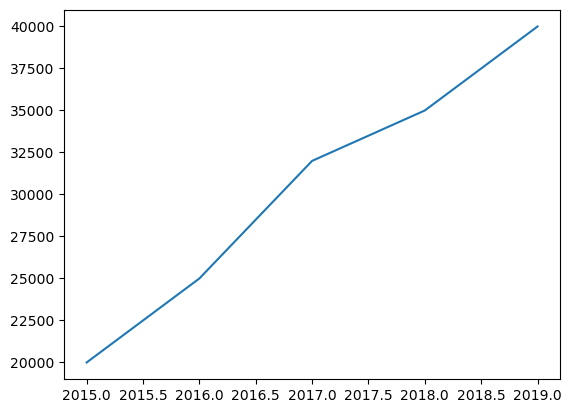

In [3]:
plt.plot(years,average_sales)

para quitar el mnensaje "[<matplotlib.lines.Line2D at 0x1d3f77d1950>] ", puedes agregar al codigo plt.show()

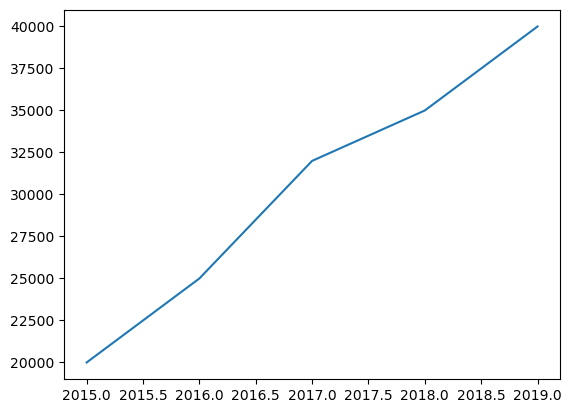

In [4]:
plt.plot(years,average_sales)
plt.show()

**Si quisieramos un grafico de barras, cambiamos plot por bar**

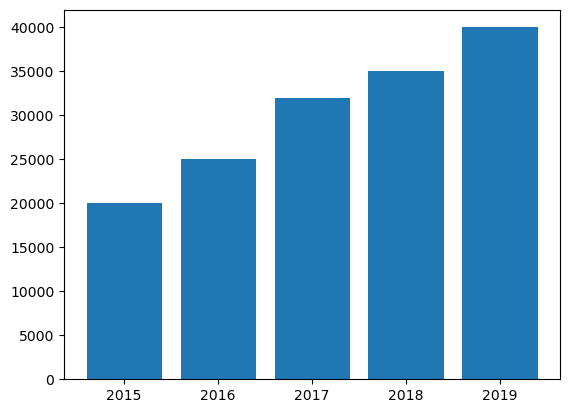

In [5]:
plt.bar(years,average_sales)
plt.show()

**Hay un monton mas de graficos, puedes verlos en la documentacion de matplotlib**

## Creating Bar Plots and Adding Annotations

In [6]:
salaries.groupby('experience_level')['salary_in_usd'].mean()

experience_level
EN     87676.762821
EX    189052.617100
MI    114681.021363
SE    161889.010574
Name: salary_in_usd, dtype: float64

**Si quisieramos ver lo anterior como dataframe, es cosa de agregar el metodo reset_index()**<br><br>
***Por ejemplo***

In [7]:
avg_salary_exp = salaries.groupby('experience_level')['salary_in_usd'].mean().reset_index() #lo guardaremos en una variable para usarlo despues
avg_salary_exp

,experience_level,salary_in_usd
0,EN,87676.762821
1,EX,189052.617100
2,MI,114681.021363
3,SE,161889.010574


**Para graficar este nuevo dataframe, lo haremos de la siguiente forma:**

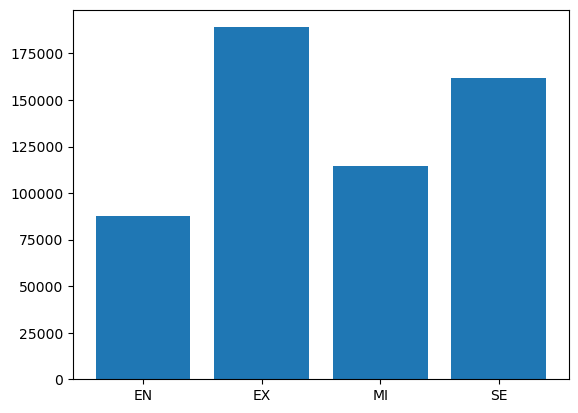

In [8]:
plt.bar(avg_salary_exp['experience_level'], avg_salary_exp['salary_in_usd'])
plt.show()

**Para ordenar los graficos de modo que la barra mas grande quede al principio, usaremos a nuestra vieja amiga sort_values() y graficaremos de la siguiente forma:**

In [9]:
avg_salary_exp = salaries.groupby('experience_level')['salary_in_usd'].mean().reset_index().sort_values(by = 'salary_in_usd', ascending = False) 
#lo guardaremos en una variable para usarlo despues
avg_salary_exp

,experience_level,salary_in_usd
1,EX,189052.617100
3,SE,161889.010574
2,MI,114681.021363
0,EN,87676.762821


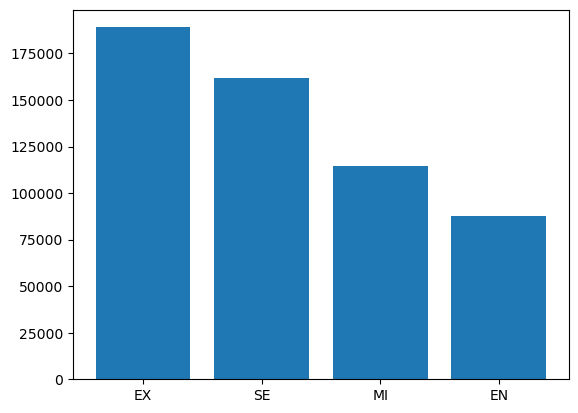

In [10]:
plt.bar(avg_salary_exp['experience_level'], avg_salary_exp['salary_in_usd'])
plt.show()

**Como podemos ver, ya funciona, pero quedo algo largo el codigo en una linea, por lo que lo acomodaremos en mas lineas, esto utilizando el backslash " \ "**

In [11]:
avg_salary_exp = salaries.groupby('experience_level')\
                ['salary_in_usd'].mean().reset_index()\
                .sort_values(by = 'salary_in_usd', ascending = False) 
#lo guardaremos en una variable para usarlo despues
avg_salary_exp

,experience_level,salary_in_usd
1,EX,189052.617100
3,SE,161889.010574
2,MI,114681.021363
0,EN,87676.762821


**Ya tenemos nuestro grafico, pero se ve algo incompleto sin etiquetas o titulo. Para agregar estos elementos, lo hacemos de la siguiente forma:**

Text(0.5, 0, 'Exp lvl')

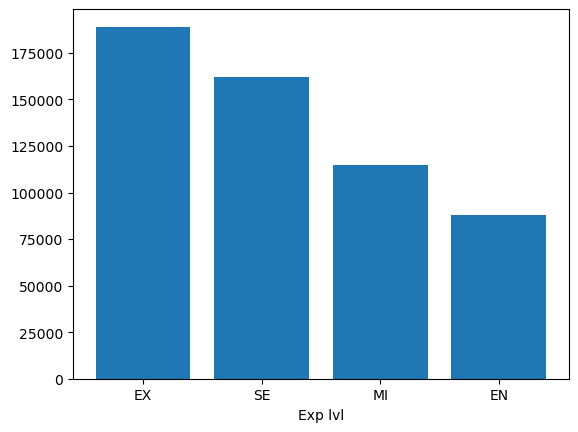

In [12]:
plt.bar(avg_salary_exp['experience_level'], avg_salary_exp['salary_in_usd'])
plt.xlabel('Exp lvl')

**IMPORTANTE: si usaremos plt.show(), siempre debe estar al final, de lo contrario devolvera dos graficos, uno vacio con las etiquetas y otro con el grafico con datos sin etiquetas.**

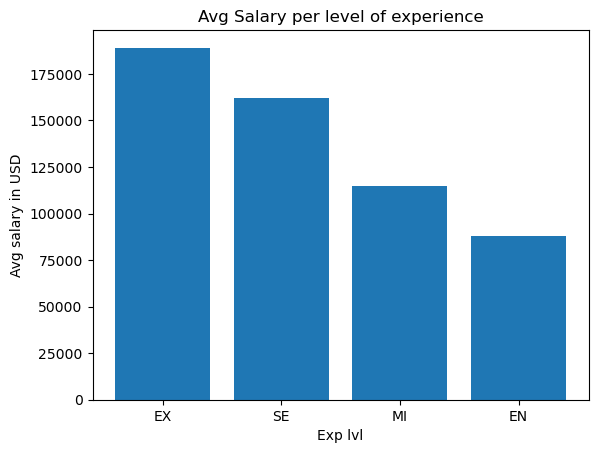

In [13]:
plt.bar(avg_salary_exp['experience_level'], avg_salary_exp['salary_in_usd'])
plt.xlabel('Exp lvl') #Define la etiqueta del eje x
plt.ylabel('Avg salary in USD') #Define la etiqueta del eje y
plt.title('Avg Salary per level of experience') #Define el titulo del grafico
plt.show()

## Visualize Data Distribution with Histograms

**Un histograma es un gráfico que muestra cómo se distribuyen los datos (Sirve para ver cuántos valores hay dentro de ciertos rangos).**
<br><br>
**Para crear un histograma rapidamente, podemos usar la funcion hist, de la siguiente forma**

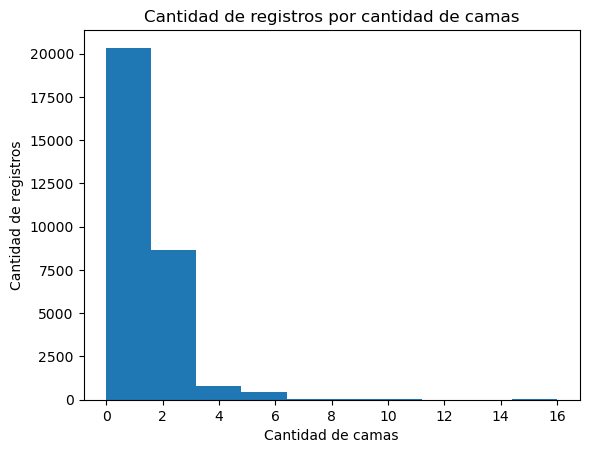

In [14]:
plt.hist(airbnb['Beds'])
plt.xlabel('Cantidad de camas')
plt.ylabel('Cantidad de registros')
plt.title('Cantidad de registros por cantidad de camas')
plt.show()

**Por defecto matplot, separa los resultados en 10 bins (grupos), pero podemos cambiar esto pasandole a la funcion el parametro bins.**
<br><br>
***Por ejemplo***

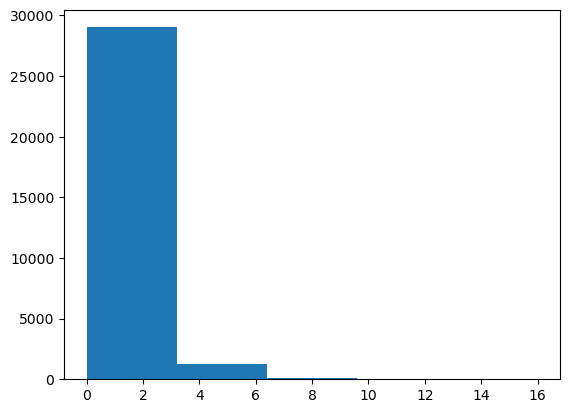

In [15]:
plt.hist(airbnb['Beds'], bins = 5) #aqui le estamos diciendo que los separe en 5 bins (grupos)
plt.show()

**Para el siguiente ejemplo, usaremos las calificaciones de cada registro, limpiando primero los NaN**

In [16]:
reviewed_airbnbs = airbnb[airbnb['Review Scores Rating'].notna()] #lo guardamos en una variable ya sin datos Nan

Ya con nuestro dataframe limpio, creamos el histograma

(array([3.9000e+01, 2.0000e+00, 4.9000e+01, 2.3000e+01, 1.5000e+01,
        3.2400e+02, 3.9100e+02, 2.1770e+03, 5.4320e+03, 1.3703e+04]),
 array([ 20.,  28.,  36.,  44.,  52.,  60.,  68.,  76.,  84.,  92., 100.]),
 <BarContainer object of 10 artists>)

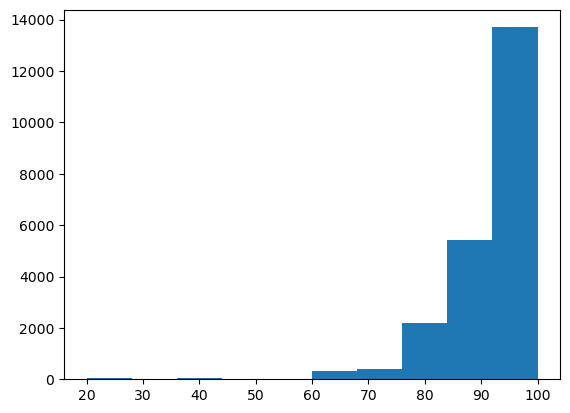

In [17]:
plt.hist(reviewed_airbnbs['Review Scores Rating'])

**Otro ejemplo con 20 bins ahora:**

(array([2.590e+02, 8.150e+02, 1.149e+03, 1.675e+03, 1.730e+03, 1.256e+03,
        8.890e+02, 5.170e+02, 2.380e+02, 1.520e+02, 6.500e+01, 3.800e+01,
        1.400e+01, 6.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 15000.  ,  45010.05,  75020.1 , 105030.15, 135040.2 , 165050.25,
        195060.3 , 225070.35, 255080.4 , 285090.45, 315100.5 , 345110.55,
        375120.6 , 405130.65, 435140.7 , 465150.75, 495160.8 , 525170.85,
        555180.9 , 585190.95, 615201.  ]),
 <BarContainer object of 20 artists>)

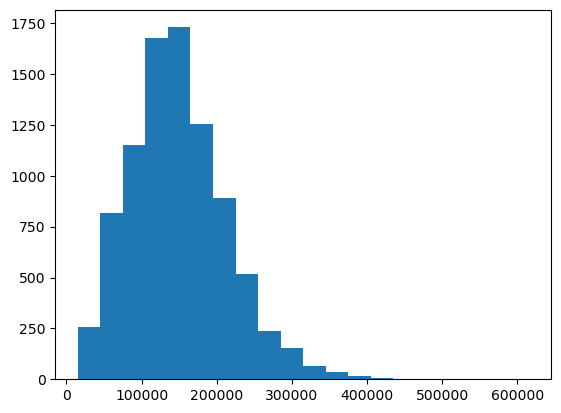

In [18]:
plt.hist(salaries['salary_in_usd'], bins = 20)

**Podemos tambien ponerle color a los bordes de las barras con el parametro edgecolor y el color de las barras con el parametro color, esto para que se vean mejor**<br><br>
***Por ejemplo***

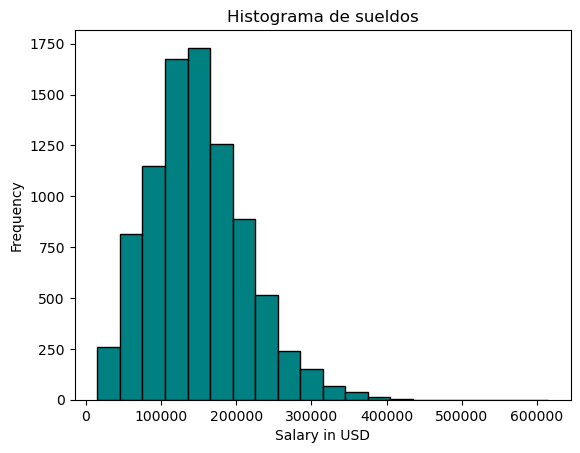

In [19]:
plt.hist(salaries['salary_in_usd'], bins = 20, edgecolor = 'black', color = 'teal')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.title('Histograma de sueldos')
plt.show()

## Display Data with Pie Charts

Los pie charts son los graficos de torta

In [20]:
countries = ['Chile','Palestina','Peru','Alemania']
profits= [200000,150000,198000,500000]

([<matplotlib.patches.Wedge at 0x21035f34590>,
 [Text(0.908154422453251, 0.6206895721522977, 'Chile'),
  Text(-0.08564765185455826, 1.0966606037110116, 'Palestina'),
  Text(-0.9906566100965668, 0.4781207806318182, 'Peru'),
  Text(0.07907146757736634, -1.0971543660830785, 'Alemania')])

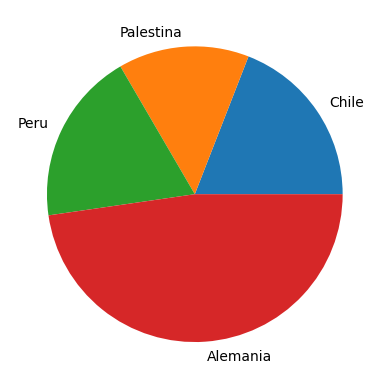

In [21]:
plt.pie(profits, labels = countries)

Ya tenemos nuestro grafico, pero esta algo vacion, para ponerle los porcentajes, podemos agregar el parametro autopct, para que nos muestre los porcentajes:

([<matplotlib.patches.Wedge at 0x21036acfb10>,
 [Text(0.908154422453251, 0.6206895721522977, 'Chile'),
  Text(-0.08564765185455826, 1.0966606037110116, 'Palestina'),
  Text(-0.9906566100965668, 0.4781207806318182, 'Peru'),
  Text(0.07907146757736634, -1.0971543660830785, 'Alemania')],
 [Text(0.4953569577017732, 0.33855794844670783, '19.1%'),
  Text(-0.04671690101157723, 0.5981785111150972, '14.3%'),
  Text(-0.5403581509617637, 0.26079315307190076, '18.9%'),
  Text(0.04312989140583618, -0.5984478360453155, '47.7%')])

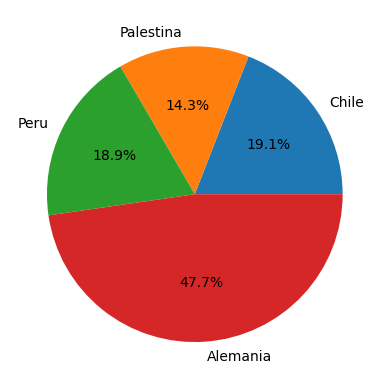

In [22]:
plt.pie(profits, labels = countries, autopct = '%1.1f%%')

**NOTA: el formato del autopct se ve algo raro, pero tiene logica, el primer porcentaje le esta diciendo a python, voy a formatear un numero, el primer entero (el 1), significa que queremos nos muestre 1 entero minimo, el segundo 1, despues del punto, significa que mostraremos un decimal, la f es por float (que es el tipo de dato de los decimales) y los ultimos porcentajes dicen literalmente "voy a añadir un porcentaje al lado del decimal"**<br><br>

Si cambiamos el segundo 1 por un 2, veremos que nos mostrara dos decimales, y si cambiamos el segundo 1 por un 0, redondeara al entero mas cercano

([<matplotlib.patches.Wedge at 0x210369cfed0>,
 [Text(0.908154422453251, 0.6206895721522977, 'Chile'),
  Text(-0.08564765185455826, 1.0966606037110116, 'Palestina'),
  Text(-0.9906566100965668, 0.4781207806318182, 'Peru'),
  Text(0.07907146757736634, -1.0971543660830785, 'Alemania')],
 [Text(0.4953569577017732, 0.33855794844670783, '19.08%'),
  Text(-0.04671690101157723, 0.5981785111150972, '14.31%'),
  Text(-0.5403581509617637, 0.26079315307190076, '18.89%'),
  Text(0.04312989140583618, -0.5984478360453155, '47.71%')])

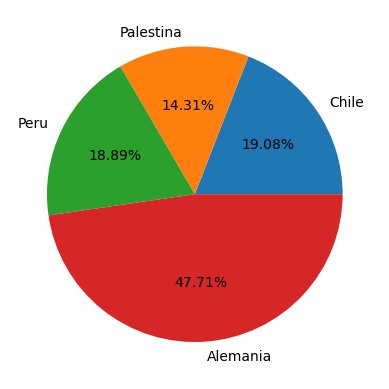

In [23]:
plt.pie(profits, labels = countries, autopct = '%1.2f%%')

([<matplotlib.patches.Wedge at 0x21036b98190>,
 [Text(0.908154422453251, 0.6206895721522977, 'Chile'),
  Text(-0.08564765185455826, 1.0966606037110116, 'Palestina'),
  Text(-0.9906566100965668, 0.4781207806318182, 'Peru'),
  Text(0.07907146757736634, -1.0971543660830785, 'Alemania')],
 [Text(0.4953569577017732, 0.33855794844670783, '19%'),
  Text(-0.04671690101157723, 0.5981785111150972, '14%'),
  Text(-0.5403581509617637, 0.26079315307190076, '19%'),
  Text(0.04312989140583618, -0.5984478360453155, '48%')])

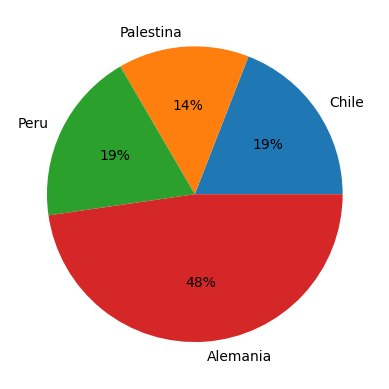

In [24]:
plt.pie(profits, labels = countries, autopct = '%1.0f%%')

***Hay muchos mas parametros con los que podemos jugar, podemos ver cuales son en la documentacion de matplotlib.pyplot***<br><br>

Usemos un ultimo parametro, el parametro explode (este permite separar un pedazo del grafico de la forma general), se usa especificando cuanto se separara cada porcion respectivamente (respeta el orden de los datos). <br><br>
Por ejemplo:


([<matplotlib.patches.Wedge at 0x21036b38550>,
 [Text(0.9907139154035465, 0.6771158968934157, 'Chile'),
  Text(-0.08564765185455826, 1.0966606037110116, 'Palestina'),
  Text(-0.9906566100965668, 0.4781207806318182, 'Peru'),
  Text(0.07907146757736634, -1.0971543660830785, 'Alemania')],
 [Text(0.5779164506520688, 0.3949842731878258, '19.1%'),
  Text(-0.04671690101157723, 0.5981785111150972, '14.3%'),
  Text(-0.5403581509617637, 0.26079315307190076, '18.9%'),
  Text(0.04312989140583618, -0.5984478360453155, '47.7%')])

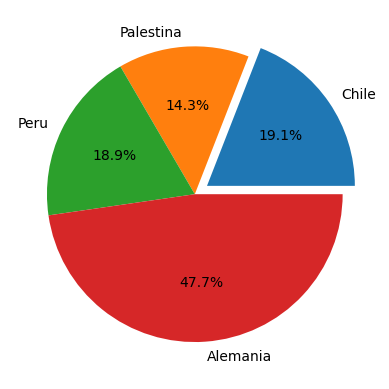

In [25]:
plt.pie(profits, labels = countries, autopct = '%1.1f%%', explode = [0.1,0,0,0])
#en este ejemplo estamos diciendole al python, separame 0.1 chile, separame 0 a palestina, separame 0 a peru y separame 0 a alemania

## Explorando relaciones con diagramas de dispersion (scatter plot)

Para los diagramas de dispersion usaremos la funcion scatter <br><br>

Por ejemplo:

In [26]:
ages = [20,25,30,35,40]
salarie = [250000, 300000,350000, 400000, 500000]

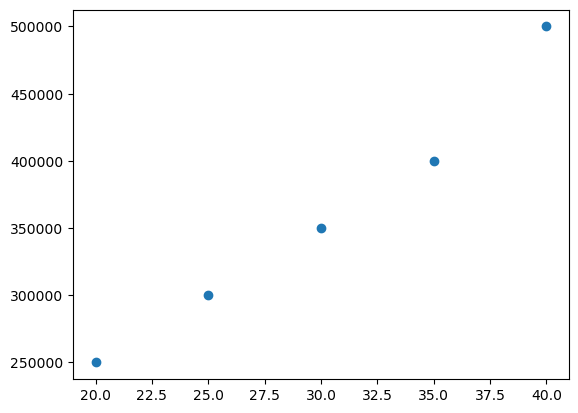

In [27]:
plt.scatter(ages, salarie)

**Nota: igual que con funciones anteriores, podemos darle parametros a esta funcion para cambiar el color por ejemplo, entre otras cosas**

Probemos con un dataframe

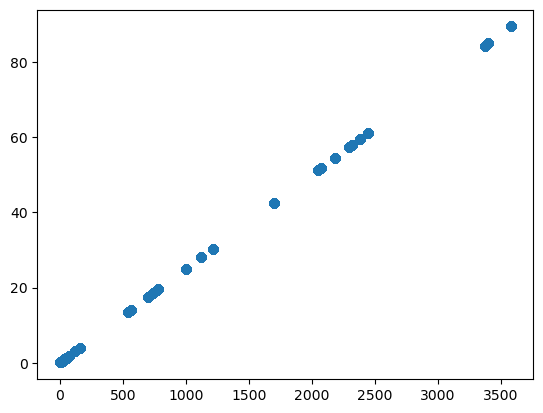

In [28]:
plt.scatter(sales['SalesAmount'], sales['Freight'])

Tambien podemos darle parametros para cambiar el marcador, por ejemplo:

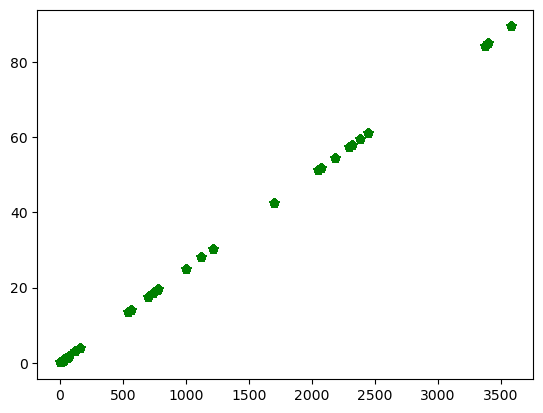

In [29]:
plt.scatter(sales['SalesAmount'], sales['Freight'], color = 'green', marker = 'p')

Hay muchas formas para el marker, investigando un poco podemos ver cuales son y como referenciarlas. En este caso usamos pentagonos.<br><br>

Podemos notar ademas que los puntos se enciman uno sobre otro haciendo dificil leer el grafico, podemos palear un poco esto con el parametro alpha, el cual nos permite definir la opcacidad de los puntos.<br><br>

**IMPORTANTE: Algunos markers no tienen relleno sólido o se dibujan como borde, y el alpha casi no se nota, haciendo parecer que la opacidad no cambio al cambiar el parametro alpha, para estos casos podemos cambiar la forma por una con relleno o forzar relleno con facecolors, de la misma forma, si tienes muchos puntos, es probable que no se note el cambio de opacidad, se puede palear un poco eso jugando con la forma, tamaño de los puntos y alphas mas bajos**

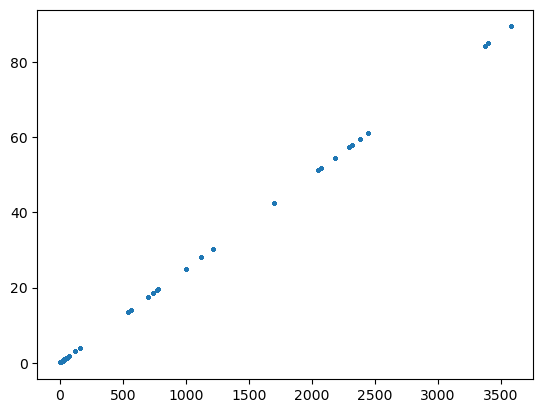

In [30]:
plt.scatter(sales['SalesAmount'], sales['Freight'], s=5, alpha = 0.02)

In [31]:
sales.shape

(60398, 11)

Aqui tenemos demasiados datos, asi que, haga lo que haga, no se notara, pero no todo esta perdido, podemos usar hexbin para casos en los que tenemos demasiados registros. <br><br>

**Por ejemplo:**

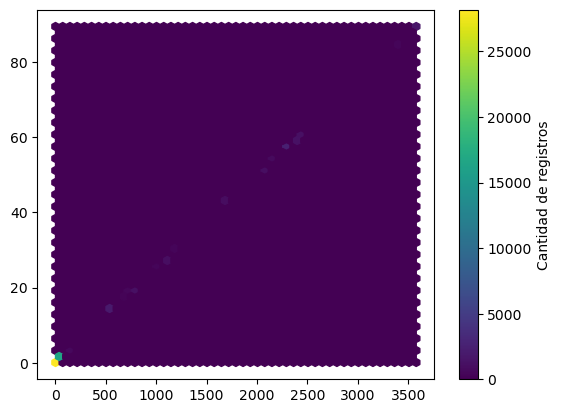

In [32]:
plt.hexbin(sales['SalesAmount'], sales['Freight'], gridsize=50)
plt.colorbar(label="Cantidad de registros")
plt.show()

Aun no se ve mucho por la cantidad de datos, en este caso chat gpt nos recomienda usar escala logaritmica e histogramas 2d (hist2d) en lugar de scatter, ya que tenemos valores pequeños y grandes mezclados. Para usar la escala logaritmica, lo haremos de la siguiente forma

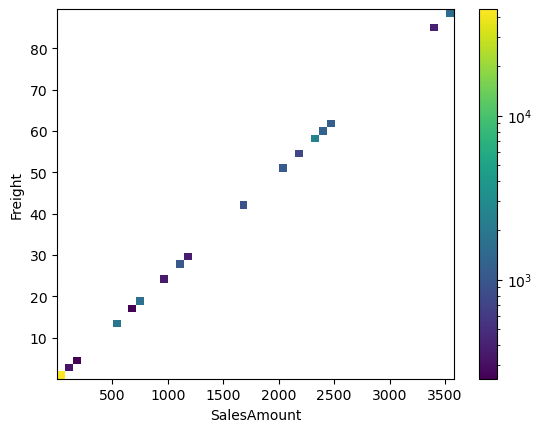

In [33]:
plt.hist2d(
    sales['SalesAmount'],
    sales['Freight'],
    bins=50,
    norm='log'
)
plt.colorbar()
plt.xlabel('SalesAmount')
plt.ylabel('Freight')
plt.show()


Como podemos ver, la escala logaritmica nos muestra mucho mejor los datos facilitando el estudio de los mismos

## Usando LinePlots (tipico grafico de lineas que se usa en economia)

In [34]:
eth

,Coin,Price,Open,High,Low,Vol.,Change %
Date,,,,,,,
10/02/2024,ETH,2508.31,2486.24,2514.83,2483.50,504.80K,0.89%
9/02/2024,ETH,2486.24,2419.56,2522.96,2419.16,540.92K,2.76%
8/02/2024,ETH,2419.56,2424.66,2461.00,2412.01,350.33K,-0.21%
7/02/2024,ETH,2424.64,2372.65,2443.71,2354.46,355.40K,2.19%
6/02/2024,ETH,2372.65,2301.83,2390.53,2299.24,381.23K,3.08%
...,...,...,...,...,...,...,...
5/01/2020,ETH,135.59,134.32,138.33,134.32,12.19M,0.94%
4/01/2020,ETH,134.33,134.30,135.57,132.76,11.16M,0.04%
3/01/2020,ETH,134.27,127.19,134.86,126.05,15.67M,5.56%


Para este ejemplo, usaremos el DF eth y consultaremos comoo se ha movido a traves del tiempo el valor. <br>
Queremos usar la fecha como eje x, pero como definimos la fecha como index, no podemos llamarlo como si fuera una columna cualquiera, por lo que lo haremos de la siguiente forma:

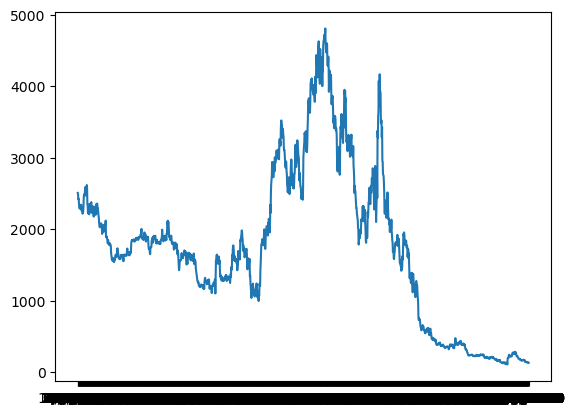

In [35]:
plt.plot(eth.index, eth['Price'])

Como podemos ver, no se entiende nada el eje x, esto es por que python esta tratando de acomodar todas las fechas y las trermina sobreponiendo, otro problema que tiene este grafico es que las etiquetas en el eje x son objetos, por lo que pone un label por cada objeto en los valores del eje x, generando este desaste de eje x, por ultimo, los datos no estan ordenados por fecha en el dataframe, lo que no se ve muy ordenado al visualizar el DF, arreglaremos todo esto de la siguiente forma:

In [36]:
eth.index = pd.to_datetime(eth.index, format = '%d/%m/%Y') #aqui estamos cambiando el tipo de variable de la fecha de objeto a datetime
eth = eth.sort_index() # Aqui lo estamos ordenando por fecha de menor a mayor

In [37]:
eth

,Coin,Price,Open,High,Low,Vol.,Change %
Date,,,,,,,
2020-01-01,ETH,130.75,129.21,132.97,128.81,10.35M,1.19%
2020-01-02,ETH,127.19,130.75,130.77,126.74,11.45M,-2.72%
2020-01-03,ETH,134.27,127.19,134.86,126.05,15.67M,5.56%
2020-01-04,ETH,134.33,134.30,135.57,132.76,11.16M,0.04%
2020-01-05,ETH,135.59,134.32,138.33,134.32,12.19M,0.94%
...,...,...,...,...,...,...,...
2024-02-06,ETH,2372.65,2301.83,2390.53,2299.24,381.23K,3.08%
2024-02-07,ETH,2424.64,2372.65,2443.71,2354.46,355.40K,2.19%
2024-02-08,ETH,2419.56,2424.66,2461.00,2412.01,350.33K,-0.21%


Text(0.5, 1.0, 'Precio historico Etherum')

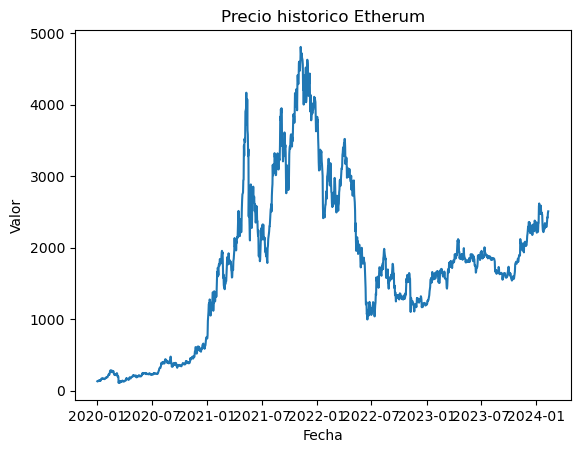

In [38]:
plt.plot(eth.index, eth['Price'])
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('Precio historico Etherum')

Ya ordenamos por fecha el dataframe y convertimos a datetime el index, pero aun se sobreponen las fechas, podemos mejorar esto, rotando un poco las etiquetas en el eje x con la funcion xticks, lo que hariamos de la siguiente forma:

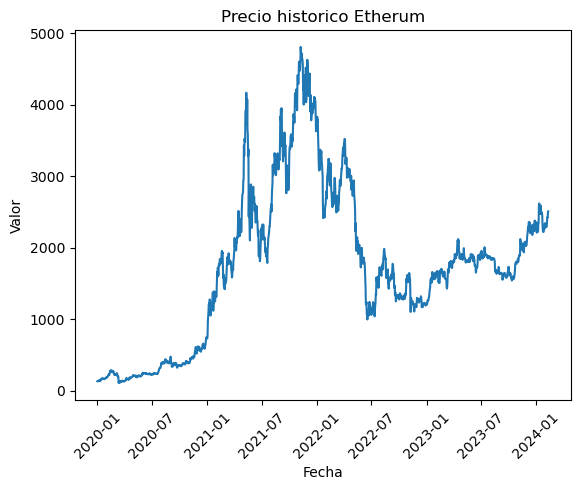

In [39]:
plt.plot(eth.index, eth['Price'])
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('Precio historico Etherum')
plt.xticks(rotation = 45) #esta es la linea que rota las etiquetas en x
plt.show()

## Structuring Visualization with Figures

**La funcion figure(), nos permite modificar cosas como el tamaño, resolucion y separar graficos**

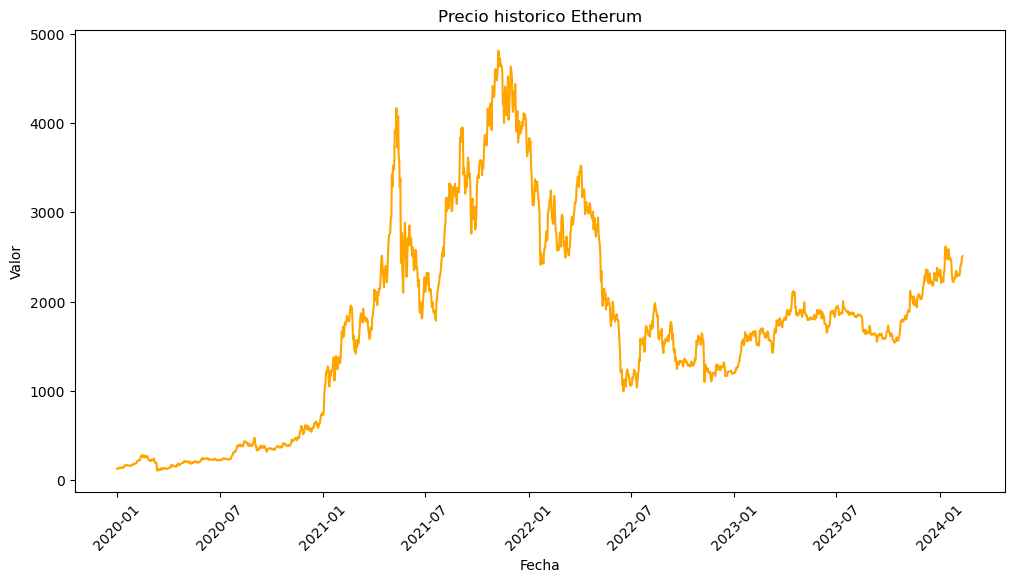

In [40]:
plt.figure(figsize =(12,6), dpi = 100) #figsize nos permite cambiar el tamaño del grafico, dpi la resolucion, siempre va antes de dibujar figure
plt.plot(eth.index, eth['Price'], color = 'orange') #Podemos cambiar el color del grafico aqui 
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('Precio historico Etherum')
plt.xticks(rotation = 45) #esta es la linea que rota las etiquetas en x
plt.show()

## Organize Plots using Subplot

Un subplot es tener varios gráficos dentro de una misma figura.

Es como dividir una hoja en varias partes y dibujar algo distinto en cada parte. 

Al utilizar subplot tiene el siguiente formato y hay que poner en numeros las filas, columans y grafico.

plt.subplot(Filas, Columnas, Gráfico)

Por ejemplo:

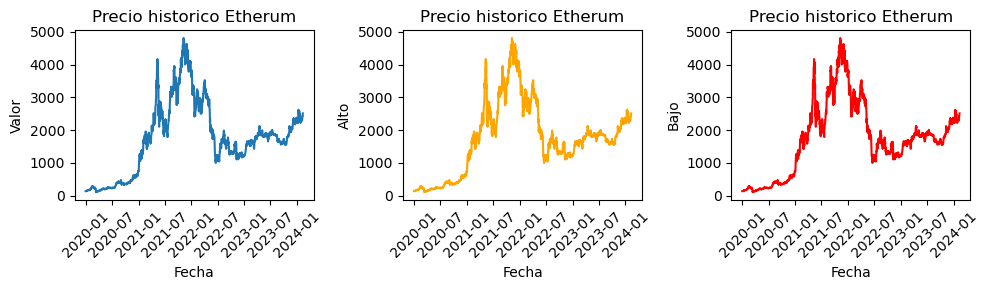

In [41]:
plt.figure(figsize =(10,3), dpi = 100) #figsize nos permite cambiar el tamaño del grafico, dpi la resolucion, siempre va antes de dibujar figure
plt.subplot(1,3,1)
plt.plot(eth.index, eth['Price']) #Podemos cambiar el color del grafico aqui 
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('Precio historico Etherum')
plt.xticks(rotation = 45) #esta es la linea que rota las etiquetas en x

plt.subplot(1,3,2)
plt.plot(eth.index, eth['Price'], color = 'orange') #Podemos cambiar el color del grafico aqui 
plt.xlabel('Fecha')
plt.ylabel('Alto')
plt.title('Precio historico Etherum')
plt.xticks(rotation = 45) #esta es la linea que rota las etiquetas en x

plt.subplot(1,3,3)
plt.plot(eth.index, eth['Price'], color = 'red') #Podemos cambiar el color del grafico aqui 
plt.xlabel('Fecha')
plt.ylabel('Bajo')
plt.title('Precio historico Etherum')
plt.xticks(rotation = 45) #esta es la linea que rota las etiquetas en x
plt.tight_layout() #Esta linea de codigo ordena los graficos de modo que no se sobrepongan las etiquetas sobre el grafico vecino
                    #tight_layout() se pone una sola vez y al final del ultimo subplot
plt.show()

## Visualizing Sales Data

In [42]:
sales

,ProductKey,product,product_subcategory,OrderDateKey,CalendarYear,SalesTerritoryRegion,SalesTerritoryCountry,SalesOrderNumber,SalesAmount,TaxAmt,Freight
0,310,"Road-150 Red, 62",Road Bikes,20101229,2010,Canada,Canada,SO43697,3578.2700,286.2616,89.4568
1,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,France,France,SO43698,3399.9900,271.9992,84.9998
2,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,Northwest,United States,SO43699,3399.9900,271.9992,84.9998
3,336,"Road-650 Black, 62",Road Bikes,20101229,2010,Southwest,United States,SO43700,699.0982,55.9279,17.4775
4,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,Australia,Australia,SO43701,3399.9900,271.9992,84.9998
...,...,...,...,...,...,...,...,...,...,...,...
60393,485,Fender Set - Mountain,Fenders,20140128,2014,Canada,Canada,SO75122,21.9800,1.7584,0.5495
60394,225,AWC Logo Cap,Caps,20140128,2014,Canada,Canada,SO75122,8.9900,0.7192,0.2248
60395,485,Fender Set - Mountain,Fenders,20140128,2014,Canada,Canada,SO75123,21.9800,1.7584,0.5495
60396,486,All-Purpose Bike Stand,Bike Stands,20140128,2014,Canada,Canada,SO75123,159.0000,12.7200,3.9750


In [44]:
sales['product_subcategory'].unique()

array(['Road Bikes', 'Mountain Bikes', 'Bottles and Cages',
       'Touring Bikes', 'Helmets', 'Tires and Tubes', 'Bike Stands',
       'Jerseys', 'Gloves', 'Fenders', 'Caps', 'Socks', 'Hydration Packs',
       'Vests', 'Cleaners', 'Bike Racks', 'Shorts'], dtype=object)

In [46]:
bike_sales = sales[sales['product_subcategory'].isin(['Road Bikes','Mountain Bikes','Touring Bikes'])]

In [47]:
bike_sales

,ProductKey,product,product_subcategory,OrderDateKey,CalendarYear,SalesTerritoryRegion,SalesTerritoryCountry,SalesOrderNumber,SalesAmount,TaxAmt,Freight
0,310,"Road-150 Red, 62",Road Bikes,20101229,2010,Canada,Canada,SO43697,3578.2700,286.2616,89.4568
1,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,France,France,SO43698,3399.9900,271.9992,84.9998
2,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,Northwest,United States,SO43699,3399.9900,271.9992,84.9998
3,336,"Road-650 Black, 62",Road Bikes,20101229,2010,Southwest,United States,SO43700,699.0982,55.9279,17.4775
4,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,Australia,Australia,SO43701,3399.9900,271.9992,84.9998
...,...,...,...,...,...,...,...,...,...,...,...
58178,606,"Road-750 Black, 52",Road Bikes,20131228,2013,United Kingdom,United Kingdom,SO74143,539.9900,43.1992,13.4998
58182,574,"Touring-1000 Blue, 50",Touring Bikes,20131228,2013,Germany,Germany,SO74144,2384.0700,190.7256,59.6018
58184,561,"Touring-1000 Yellow, 46",Touring Bikes,20131228,2013,Australia,Australia,SO74145,2384.0700,190.7256,59.6018
58185,584,"Road-750 Black, 58",Road Bikes,20131228,2013,Australia,Australia,SO74146,539.9900,43.1992,13.4998


In [62]:
bike_sales_grp = bike_sales.groupby('product_subcategory')['SalesAmount'].sum()\
    .reset_index().sort_values(by = 'SalesAmount', ascending = False)

In [63]:
bike_sales_grp

,product_subcategory,SalesAmount
1,Road Bikes,1.452058e+07
0,Mountain Bikes,9.952760e+06
2,Touring Bikes,3.844801e+06


In [50]:
other_sales = sales[~sales['product_subcategory'].isin(['Road Bikes','Mountain Bikes','Touring Bikes'])]

In [80]:
other_sales_grp = other_sales.groupby('product_subcategory')['SalesAmount'].sum()\
    .reset_index().sort_values(by = 'SalesAmount')

In [81]:
other_sales_grp

,product_subcategory,SalesAmount
11,Socks,5106.32
4,Cleaners,7218.60
3,Caps,19688.10
6,Gloves,35020.70
13,Vests,35687.00
0,Bike Racks,39360.00
1,Bike Stands,39591.00
8,Hydration Packs,40307.67
5,Fenders,46619.58
2,Bottles and Cages,56798.19


Graficando nuestros dataframes

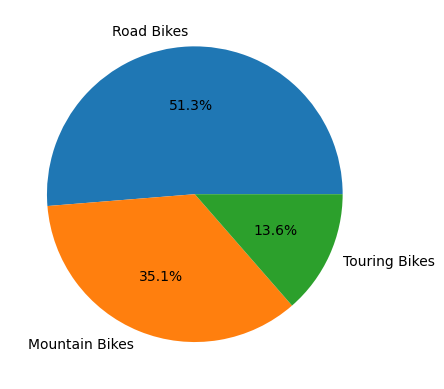

In [82]:
plt.pie(bike_sales_grp['SalesAmount'], labels = bike_sales_grp['product_subcategory'], autopct = '%1.1f%%')
plt.show()

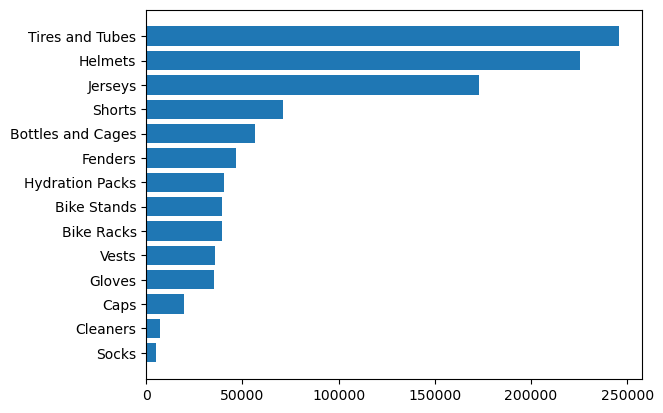

In [83]:
plt.barh(other_sales_grp['product_subcategory'], other_sales_grp['SalesAmount'])
plt.show()

In [92]:
sales['OrderDate'] = pd.to_datetime(sales['OrderDateKey'], format = '%Y%m%d') #creamos columna con la fecha en datetime
sales['MonthYear'] = sales['OrderDate'].dt.strftime('%Y-%m')

In [93]:
sales

,ProductKey,product,product_subcategory,OrderDateKey,CalendarYear,SalesTerritoryRegion,SalesTerritoryCountry,SalesOrderNumber,SalesAmount,TaxAmt,Freight,OrderDate,MonthYear
0,310,"Road-150 Red, 62",Road Bikes,20101229,2010,Canada,Canada,SO43697,3578.2700,286.2616,89.4568,2010-12-29,2010-12
1,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,France,France,SO43698,3399.9900,271.9992,84.9998,2010-12-29,2010-12
2,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,Northwest,United States,SO43699,3399.9900,271.9992,84.9998,2010-12-29,2010-12
3,336,"Road-650 Black, 62",Road Bikes,20101229,2010,Southwest,United States,SO43700,699.0982,55.9279,17.4775,2010-12-29,2010-12
4,346,"Mountain-100 Silver, 44",Mountain Bikes,20101229,2010,Australia,Australia,SO43701,3399.9900,271.9992,84.9998,2010-12-29,2010-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,485,Fender Set - Mountain,Fenders,20140128,2014,Canada,Canada,SO75122,21.9800,1.7584,0.5495,2014-01-28,2014-01
60394,225,AWC Logo Cap,Caps,20140128,2014,Canada,Canada,SO75122,8.9900,0.7192,0.2248,2014-01-28,2014-01
60395,485,Fender Set - Mountain,Fenders,20140128,2014,Canada,Canada,SO75123,21.9800,1.7584,0.5495,2014-01-28,2014-01
60396,486,All-Purpose Bike Stand,Bike Stands,20140128,2014,Canada,Canada,SO75123,159.0000,12.7200,3.9750,2014-01-28,2014-01


In [94]:
monthly_sales = sales.groupby('MonthYear')['SalesAmount'].sum().reset_index() 

<function matplotlib.pyplot.show(close=None, block=None)>

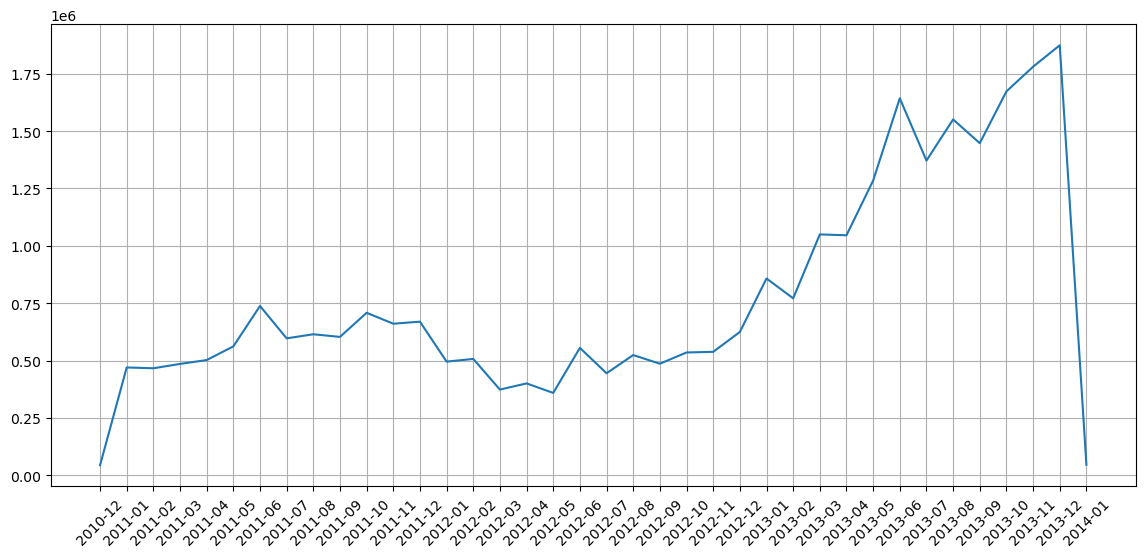

In [103]:
plt.figure(figsize=(14,6))
plt.plot(monthly_sales['MonthYear'], monthly_sales['SalesAmount'])
plt.xticks(rotation = 45)
plt.grid()
plt.show

In [104]:
monthly_sales

,MonthYear,SalesAmount
0,2010-12,4.342104e+04
1,2011-01,4.698239e+05
2,2011-02,4.663349e+05
3,2011-03,4.851987e+05
4,2011-04,5.020738e+05
5,2011-05,5.616815e+05
6,2011-06,7.378398e+05
7,2011-07,5.967466e+05
8,2011-08,6.145579e+05
9,2011-09,6.030835e+05


**Nota 1: Cada subplot o grafico individual corresponde a un eje (axes)**

**Nota 2: Al definir las dimensiones de la grilla en los subplots, no es necesario que se usen todos los espacios, podemos dejar en blanco algunos, por ejemplo; podemos hacer una grilla de 2 filas x 2 columnas y dejar el espacio 4 (inferior derecho) vacio**

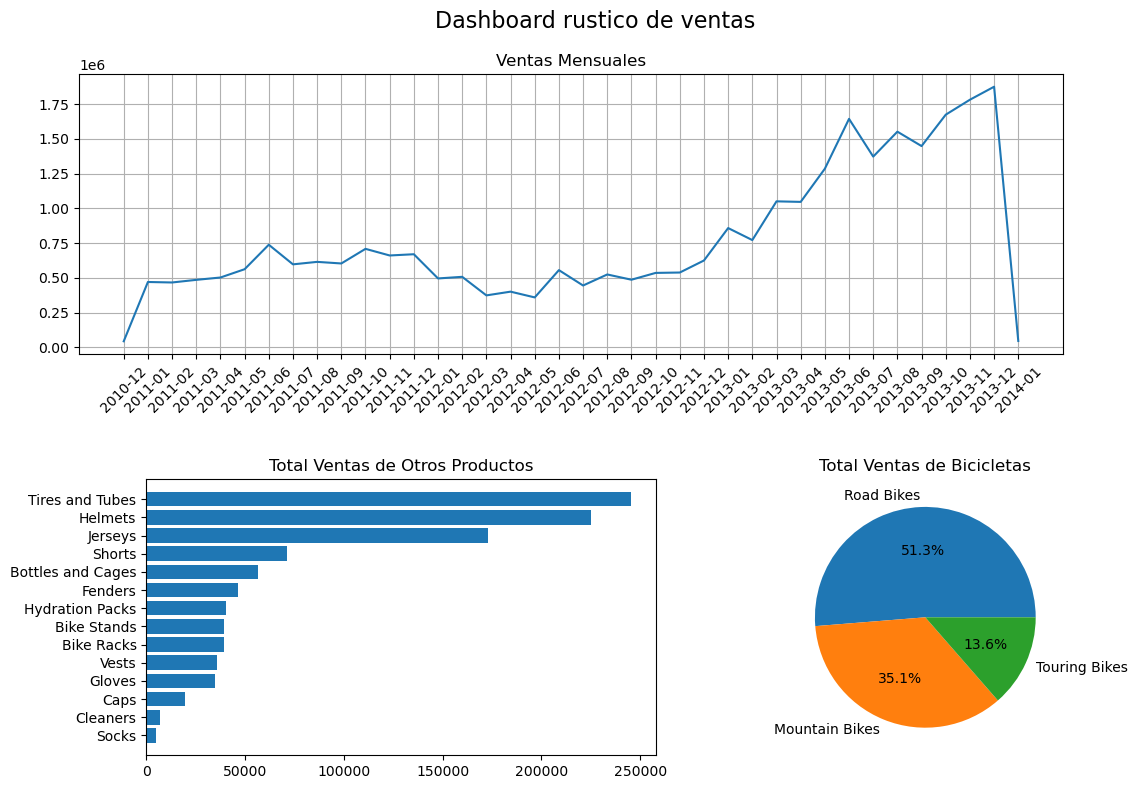

In [122]:
plt.figure(figsize=(12,8))

plt.suptitle('Dashboard rustico de ventas', fontsize=16)

plt.subplot(2,2,(1,2))
# Creamos una grilla de 2 filas x 2 columnas
# y este gráfico ocupa los espacios 1 y 2 (toda la fila superior)

plt.plot(monthly_sales['MonthYear'], monthly_sales['SalesAmount'])
plt.xticks(rotation=45)
plt.grid()
plt.title('Ventas Mensuales')

ax = plt.gca()
# GCA = Get Current Axes
# Obtiene el eje (subplot) actualmente activo.
# En este punto, el eje activo es el gráfico superior,
# por lo que ax representa SOLO este subplot.
# El objeto ax permite modificar propiedades del eje como:
# - posición (set_position)
# - título (set_title)
# - limite visible de x (.set_xlim()) 
# - Limite visible de y (.set_ylim())


plt.subplot(2,2,3)
# Subplot inferior izquierdo (posición 3)
plt.barh(other_sales_grp['product_subcategory'], other_sales_grp['SalesAmount'])
plt.title('Total Ventas de Otros Productos')


plt.subplot(2,2,4)
# Subplot inferior derecho (posición 4)
plt.pie(
    bike_sales_grp['SalesAmount'],
    labels=bike_sales_grp['product_subcategory'],
    autopct='%1.1f%%'
)
plt.title('Total Ventas de Bicicletas')


plt.tight_layout(rect=[0, 0, 1, 0.95])
# Ajusta automáticamente los espacios entre subplots
# El parámetro rect define los margenes de la figura y en este caso deja un margen superior para el suptitle
# La sintaxis de este parametro (rect) es: rect = [margen izquierdo, margen inferior, margen derecho, margen superior]

ax.set_position([0.07, 0.55, 0.82, 0.35])
# Mueve y redimensiona SOLO el gráfico superior, recordemos que el eje correspondiente al primer subplot quedo en la variable ax que definimos arriba
# Formato/Sintaxis: .set_position[left, bottom, width, height]
# IMPORTANTE: set_position debe ir DESPUÉS de tight_layout(), de lo contrario tight_layout sobrescribe las posiciones que definimos con set_position

plt.show()


**En el ejemplo anterior yo hice mi propio estilo personalizado de dashboard, pero, existen estilos ya previamente creados que podemos usar.**

**Podemos ver la lista de estilos con la linea de codigo plt.style.available**

In [123]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

**Para el proximo ejemplo usare el estilo 'seaborn-v0_8-pastel'**

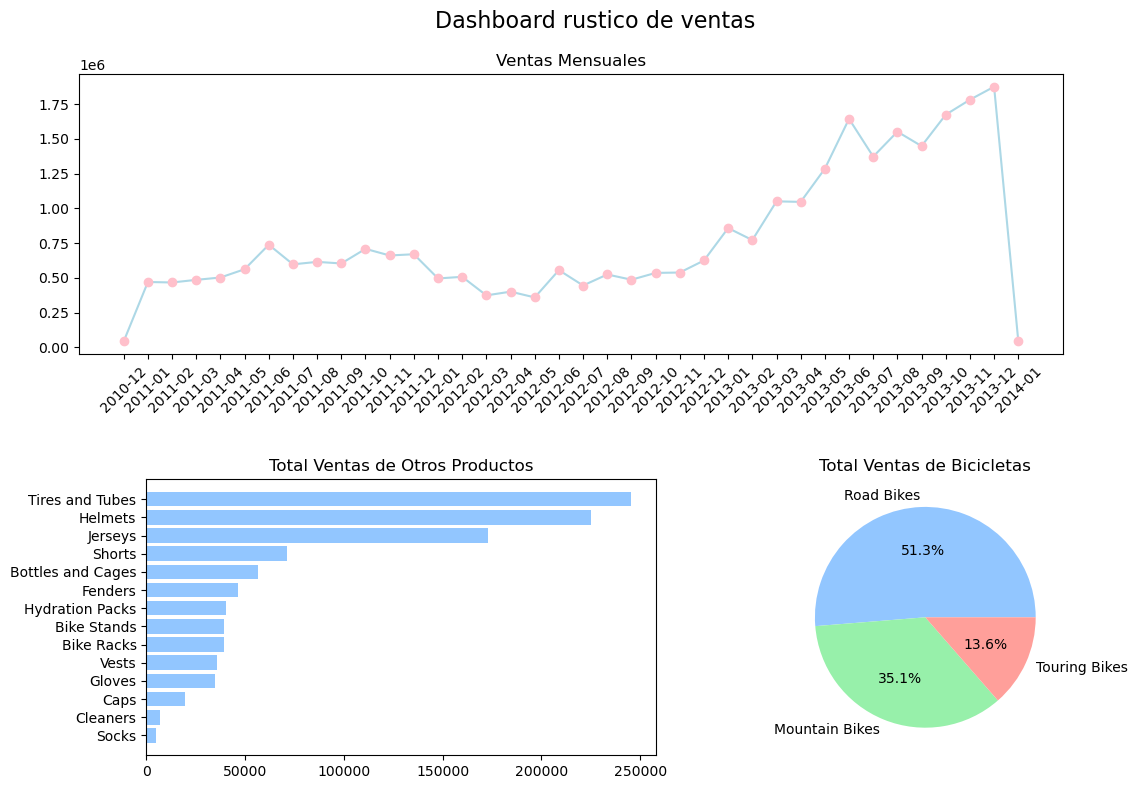

In [131]:
plt.style.use('seaborn-v0_8-pastel')

plt.figure(figsize=(12,8))

plt.suptitle('Dashboard rustico de ventas', fontsize=16)

plt.subplot(2,2,(1,2))
plt.plot(
    monthly_sales['MonthYear'], 
    monthly_sales['SalesAmount'], 
    marker = 'o', 
    color ='lightblue', 
    markerfacecolor = 'pink', 
    markeredgecolor = 'pink'
) 
#Marker nos permite añadir marcadores de posicion en la linea.
#color nos permite cambiar el color de la linea o de la linea y los markers si no definimos parametros para markerfacecolor y markeredgecolor
#markerfacecolor cambia el color del relleno del marker
#markeredgecolor cambia el color del borde del marker
#Hay mas parametros para mover que nos permiten modificar el estilo de la linea el grosor, tamaño y color de fuete, etc
plt.xticks(rotation=45)
plt.title('Ventas Mensuales')

ax = plt.gca()
plt.subplot(2,2,3)
plt.barh(other_sales_grp['product_subcategory'], other_sales_grp['SalesAmount'])
plt.title('Total Ventas de Otros Productos')


plt.subplot(2,2,4)
plt.pie(
    bike_sales_grp['SalesAmount'],
    labels=bike_sales_grp['product_subcategory'],
    autopct='%1.1f%%'
)
plt.title('Total Ventas de Bicicletas')
plt.tight_layout(rect=[0, 0, 1, 0.95])
ax.set_position([0.07, 0.55, 0.82, 0.35])

plt.show()